##2: Data Collection

###Import necessary libraries

In [ ]:
import tensorflow as tf
import keras
from keras.layers import Input,Conv2D,MaxPooling2D,UpSampling2D,BatchNormalization,Concatenate
from tensorflow.keras.models import Model,load_model
from matplotlib import pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')


###Load Data

In [ ]:
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32
EPOCHS = 100
NOISE_FACTOR = 0.2

In [ ]:
train_path = '/content/drive/MyDrive/Color_Autoencoder/Small_Dataset/train'
test_path = '/content/drive/MyDrive/Color_Autoencoder/Small_Dataset/test'

##3.Data Preparation

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels= None,
    image_size = (IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 200 files.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels= None,
    image_size = (IMG_HEIGHT,IMG_WIDTH),
    batch_size = BATCH_SIZE,
    shuffle = True
)


Found 40 files.


###Normalizing

In [ ]:
print(type(train_dataset))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [ ]:
train_dataset = train_dataset.map(lambda x: x/255.0)
test_dataset = test_dataset.map(lambda x: x/255.0)

###Add Noise

In [ ]:
def add_noise(images):

  noise = tf.random.normal(
      shape = tf.shape(images)
  )

  noisy_images = images + NOISE_FACTOR * noise

  noise_images = tf.clip_by_value(

        noisy_images,
        0.0,
        1.0
  )

  return noisy_images, images


###Apply Noise

In [ ]:
train_dataset = train_dataset.map(
    add_noise
)
test_dataset = test_dataset.map(
    add_noise
)


###Visualize a batch of images

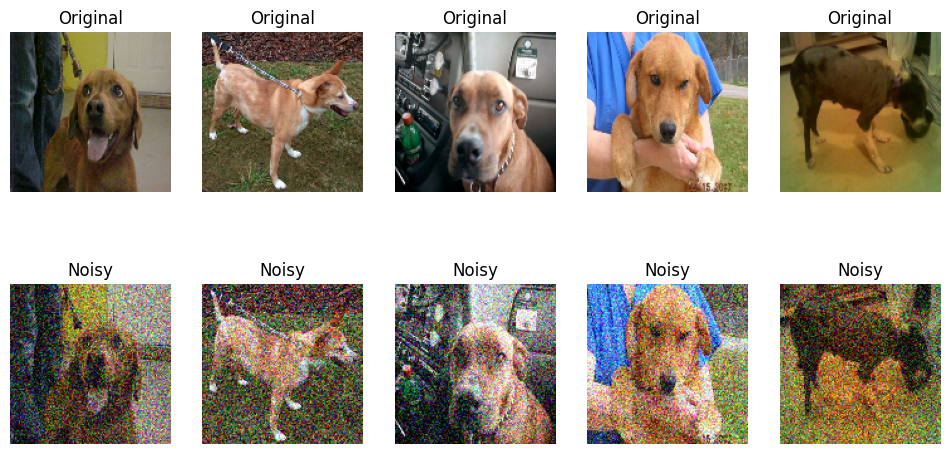

In [ ]:
for noisy_images, original_images in train_dataset.take(1):

    plt.figure(figsize=(12,6))

    for i in range(5):

        plt.subplot(2,5,i+1)

        plt.imshow(original_images[i])

        plt.axis("off")

        plt.title("Original")

        plt.subplot(2,5,i+6)

        plt.imshow(noisy_images[i])

        plt.axis("off")

        plt.title("Noisy")

    plt.show()

##4. Model Building

In [ ]:
input_image = Input(shape=(IMG_HEIGHT,IMG_WIDTH,3))


###Encoder

In [ ]:
# input_image = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
# x = Conv2D(32, (3,3), activation="relu", padding="same")(input_image)
# x = BatchNormalization()(x)

# x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
# x = BatchNormalization()(x)

# x = MaxPooling2D((2,2), padding="same")(x)

# x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
# x = BatchNormalization()(x)

# x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
# x = BatchNormalization()(x)

# x = MaxPooling2D((2,2), padding="same")(x)

# x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
# x = BatchNormalization()(x)

# x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
# x = BatchNormalization()(x)

# encoded = MaxPooling2D((2,2), padding="same")(x)

###Decoder

In [ ]:

input_image = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# ====================================
# ENCODER
# ====================================

# Block 1

c1 = Conv2D(32,(3,3),activation="relu",padding="same")(input_image)
c1 = BatchNormalization()(c1)

c1 = Conv2D(32,(3,3),activation="relu",padding="same")(c1)
c1 = BatchNormalization()(c1)

p1 = MaxPooling2D((2,2),padding="same")(c1)

# ------------------------------------

# Block 2

c2 = Conv2D(64,(3,3),activation="relu",padding="same")(p1)
c2 = BatchNormalization()(c2)

c2 = Conv2D(64,(3,3),activation="relu",padding="same")(c2)
c2 = BatchNormalization()(c2)

p2 = MaxPooling2D((2,2),padding="same")(c2)

# ------------------------------------

# Block 3

c3 = Conv2D(128,(3,3),activation="relu",padding="same")(p2)
c3 = BatchNormalization()(c3)

c3 = Conv2D(128,(3,3),activation="relu",padding="same")(c3)
c3 = BatchNormalization()(c3)

p3 = MaxPooling2D((2,2),padding="same")(c3)

# ====================================
# BOTTLENECK
# ====================================

b = Conv2D(256,(3,3),activation="relu",padding="same")(p3)
b = BatchNormalization()(b)

b = Conv2D(256,(3,3),activation="relu",padding="same")(b)
b = BatchNormalization()(b)

# ====================================
# DECODER
# ====================================

# Block 1

u1 = UpSampling2D((2,2))(b)

u1 = Concatenate()([u1,c3])

u1 = Conv2D(128,(3,3),activation="relu",padding="same")(u1)
u1 = BatchNormalization()(u1)

u1 = Conv2D(128,(3,3),activation="relu",padding="same")(u1)
u1 = BatchNormalization()(u1)

# ------------------------------------

# Block 2

u2 = UpSampling2D((2,2))(u1)

u2 = Concatenate()([u2,c2])

u2 = Conv2D(64,(3,3),activation="relu",padding="same")(u2)
u2 = BatchNormalization()(u2)

u2 = Conv2D(64,(3,3),activation="relu",padding="same")(u2)
u2 = BatchNormalization()(u2)

# ------------------------------------

# Block 3

u3 = UpSampling2D((2,2))(u2)

u3 = Concatenate()([u3,c1])

u3 = Conv2D(32,(3,3),activation="relu",padding="same")(u3)
u3 = BatchNormalization()(u3)

u3 = Conv2D(32,(3,3),activation="relu",padding="same")(u3)
u3 = BatchNormalization()(u3)

# ====================================
# OUTPUT
# ====================================

decoded = Conv2D(
    3,
    (3,3),
    activation="sigmoid",
    padding="same"
)(u3)



###Model Compilation

In [ ]:
autoencoder = Model(
    inputs =input_image,
    outputs= decoded
)

In [ ]:
autoencoder.compile(optimizer='adam',loss='mse')

In [ ]:
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 128, 128,  │        896 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_103[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_104[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_30    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 64, 64,    │     18,496 │ max_pooling2d_30… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_105[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_106[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 32, 32,    │     73,856 │ max_pooling2d_31… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_107[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_108[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 16, 16,    │    295,168 │ max_pooling2d_32

 Total params: 1,953,347 (7.45 MB)

 Trainable params: 1,950,531 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

##5.Model Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = autoencoder.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - loss: 0.0492 - val_loss: 0.1944
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - loss: 0.0125 - val_loss: 0.2377
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0083 - val_loss: 0.1654
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0074 - val_loss: 0.1327
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0069 - val_loss: 0.0708
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 0.0063 - val_loss: 0.0469
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0061 - val_loss: 0.0406
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0057 - val_loss: 0.0364
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.0060 - val_loss: 0.0339
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - loss: 0.0054 - val_loss: 0.0402
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - loss: 0.0053 - val_loss: 0.0331
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 0.005

###Plot Training vs Validation loss

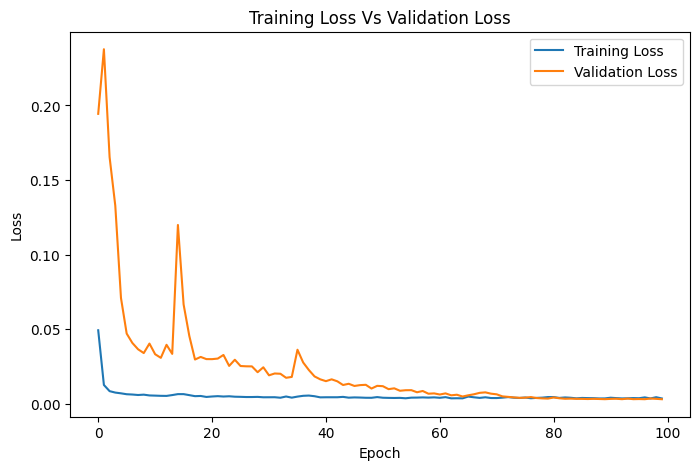

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
    label = 'Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label = 'Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
loss = autoencoder.evaluate(test_dataset)
print('Test Data Loss:',loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0029 
Test Data Loss: 0.002900716383010149


##6.Model Testing

In [ ]:
predictions = autoencoder.predict(test_dataset)
predictions.shape

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


(40, 128, 128, 3)

###Displaying the original, noisy and denoised image

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


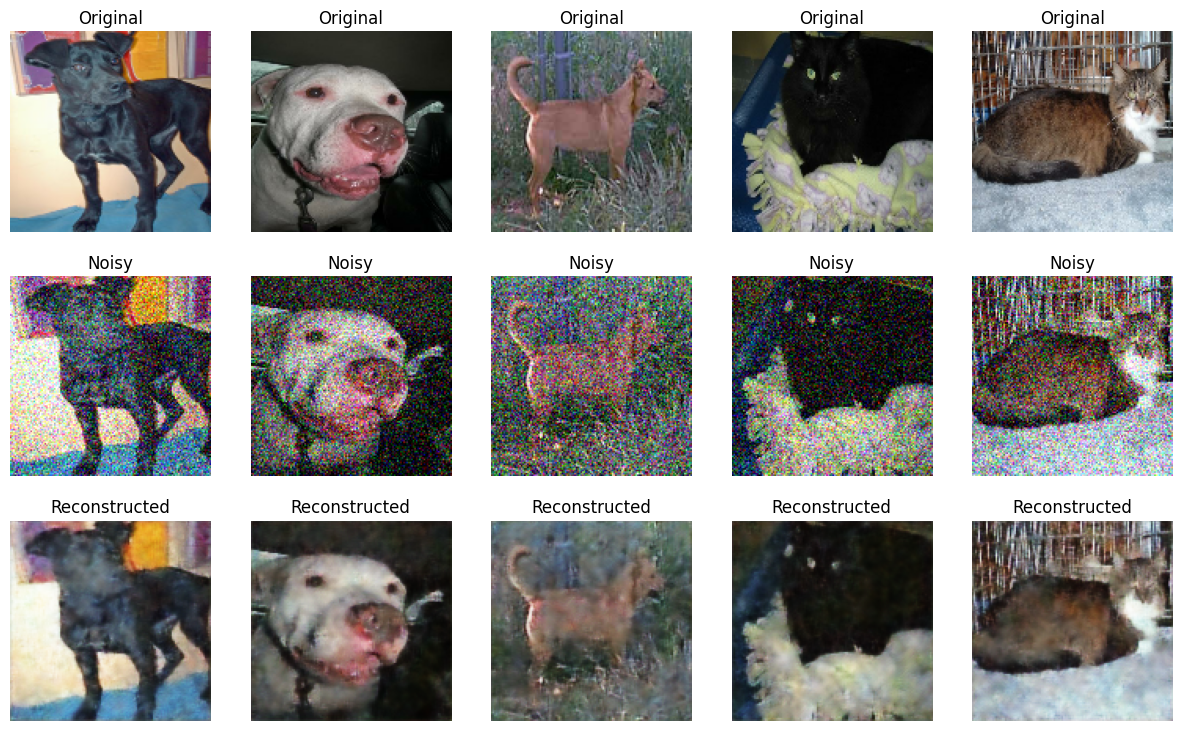

In [ ]:
for noisy_images,original_images in test_dataset.take(1):
  reconstructed_images = autoencoder.predict(noisy_images)
  plt.figure(figsize=(15,9))
  for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(original_images[i])
    plt.axis('off')
    plt.title('Original')

    plt.subplot(3,5,i+6)
    plt.imshow(noisy_images[i])
    plt.axis('off')
    plt.title('Noisy')

    plt.subplot(3,5,i+11)
    plt.imshow(reconstructed_images[i])
    plt.axis('off')
    plt.title('Reconstructed')


  plt.show()

  break


In [ ]:
autoencoder.save('U_net_autoencoders.h5')

In [ ]:
color_image_intel = load_model('U_net_autoencoders.h5', compile=False)

###Testing the Resconstruction through unseen images

In [ ]:
from tensorflow.keras.preprocessing import image
image_path = "/content/Screenshot 2026-07-26 140751.png"
img = image.load_img(
    image_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
noise = tf.random.normal(
      shape = tf.shape(img_array)
  )

noisy_image = img_array + NOISE_FACTOR * noise

noise_image = tf.clip_by_value(

        noisy_image,
        0.0,
        1.0
  )

###Prediction
reconstructed = color_image_intel.predict(noisy_image)

##Reducing the batch dimensions
original = img_array[0]

noisy = noisy_image.numpy()[0]

reconstructed = reconstructed[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


###Displaying the Reconstruction

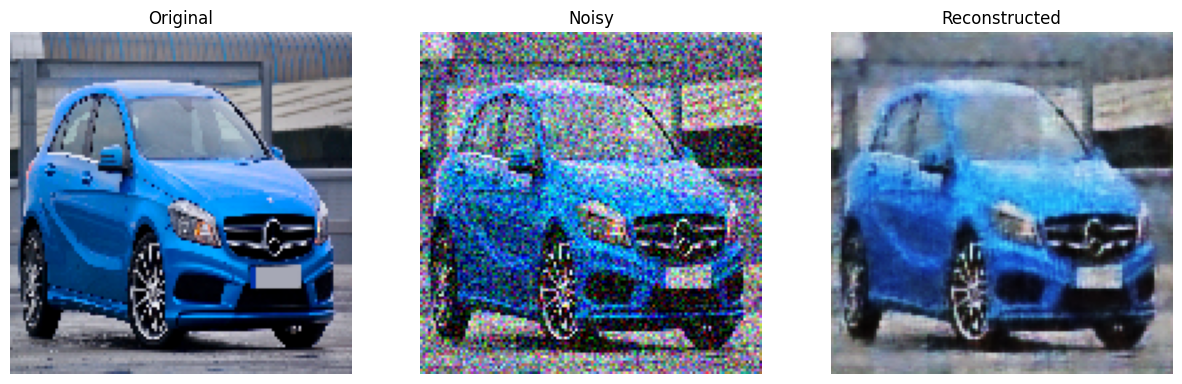

In [ ]:
plt.figure(figsize=(15,5))

# Original

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

# Noisy

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis("off")

# Reconstructed

plt.subplot(1,3,3)
plt.imshow(reconstructed)
plt.title("Reconstructed")
plt.axis("off")

plt.show()

In [ ]:
print(reconstructed.shape)
print(type(reconstructed))

(128, 3)
<class 'numpy.ndarray'>


In [ ]:
print(reconstructed.min())
print(reconstructed.max())

0.39439127
0.8212416
